In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

In [24]:
#creating database connection
conn=sqlite3.connect('inventory.db')

#fetching vendor summary data
df=pd.read_sql_query("select * from Vendor_sales_summary",conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,actualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.037271,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.042125,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.054746,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.061453,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.044932,1.396897


## Exploratory Data Analysis
1. Previously  we examined the various tables in the database to identify key varibales ,understand their relationships,and determine which ones should be included in the final analysis.
2. In this phase of EDA,we will analyze the resultant table to gain insights into the distribution of each column.This will helps us understand data patterns ,identify anomalies and ensure data quality before proceeding with further analysis.

In [25]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,1.065065e+04,18753.519148,2.00,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,1.803923e+04,12662.187074,58.00,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,2.438530e+01,109.269375,0.36,6.840000,10.455000,19.482500,5.681810e+03
actualPrice,10692.0,3.564367e+01,148.246016,0.49,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,8.473605e+02,664.309212,50.00,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3.140887e+03,11095.086769,1.00,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,3.010669e+04,123067.799627,0.71,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3.077482e+03,10952.851391,0.00,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,4.223907e+04,167655.265984,0.00,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,1.879378e+04,44952.773386,0.00,289.710000,2857.800000,16059.562500,6.728193e+05


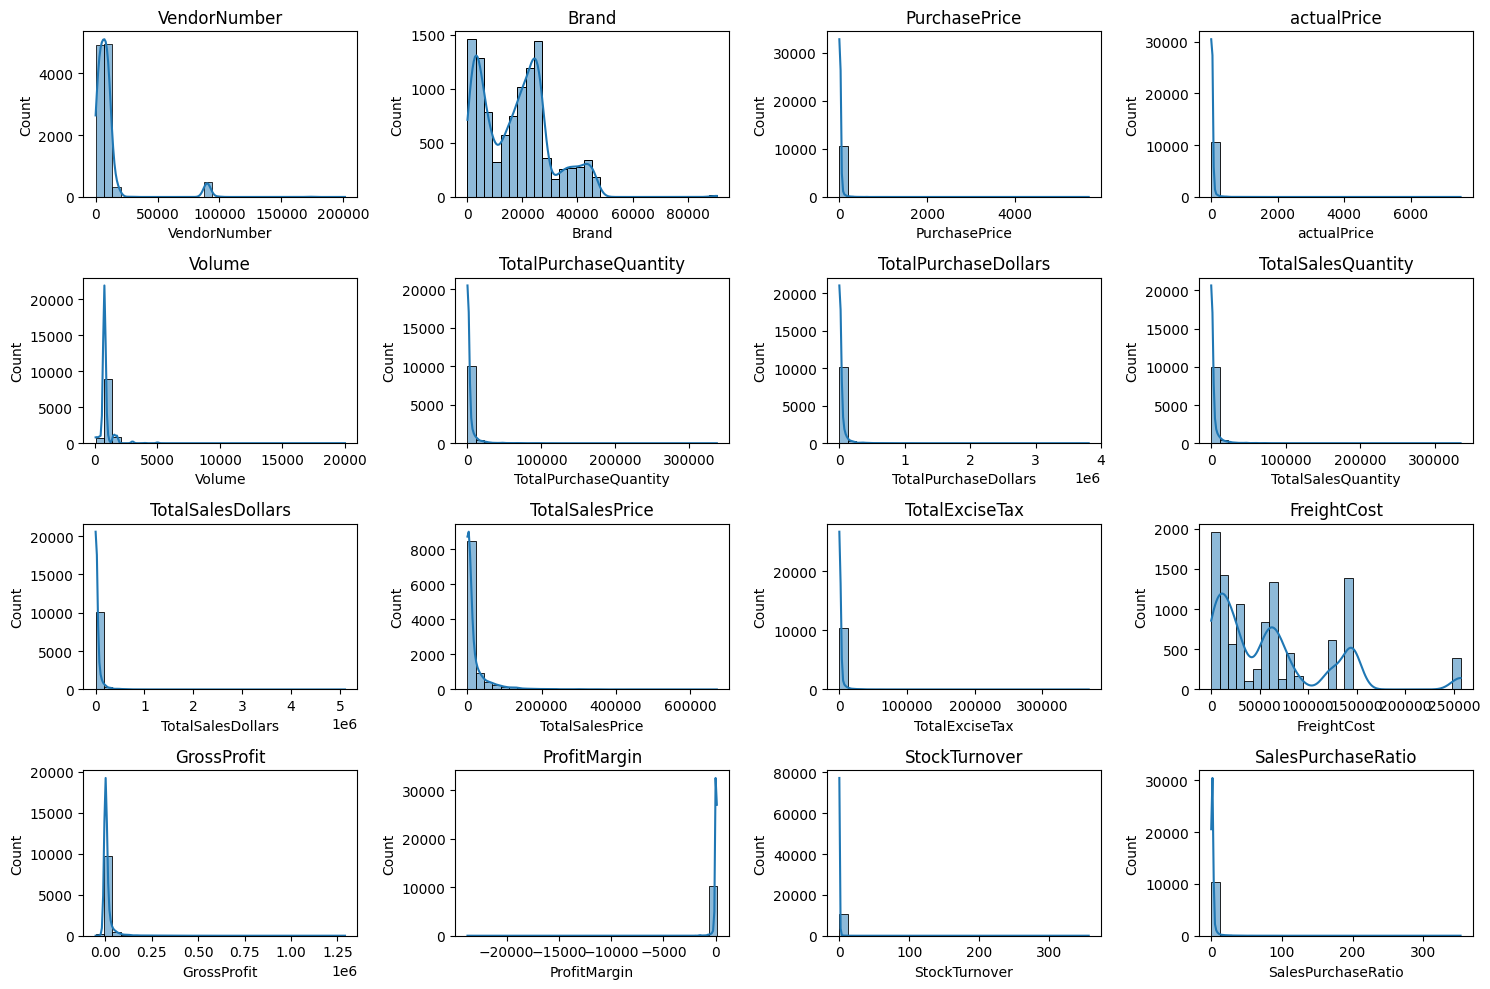

In [26]:
#Distribution plots for Numerical Values
numerical_cols=df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i ,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
    plt.tight_layout()
plt.savefig("analysis/numerical_distribution_plots_01.png", dpi=300)
plt.show()

    
    

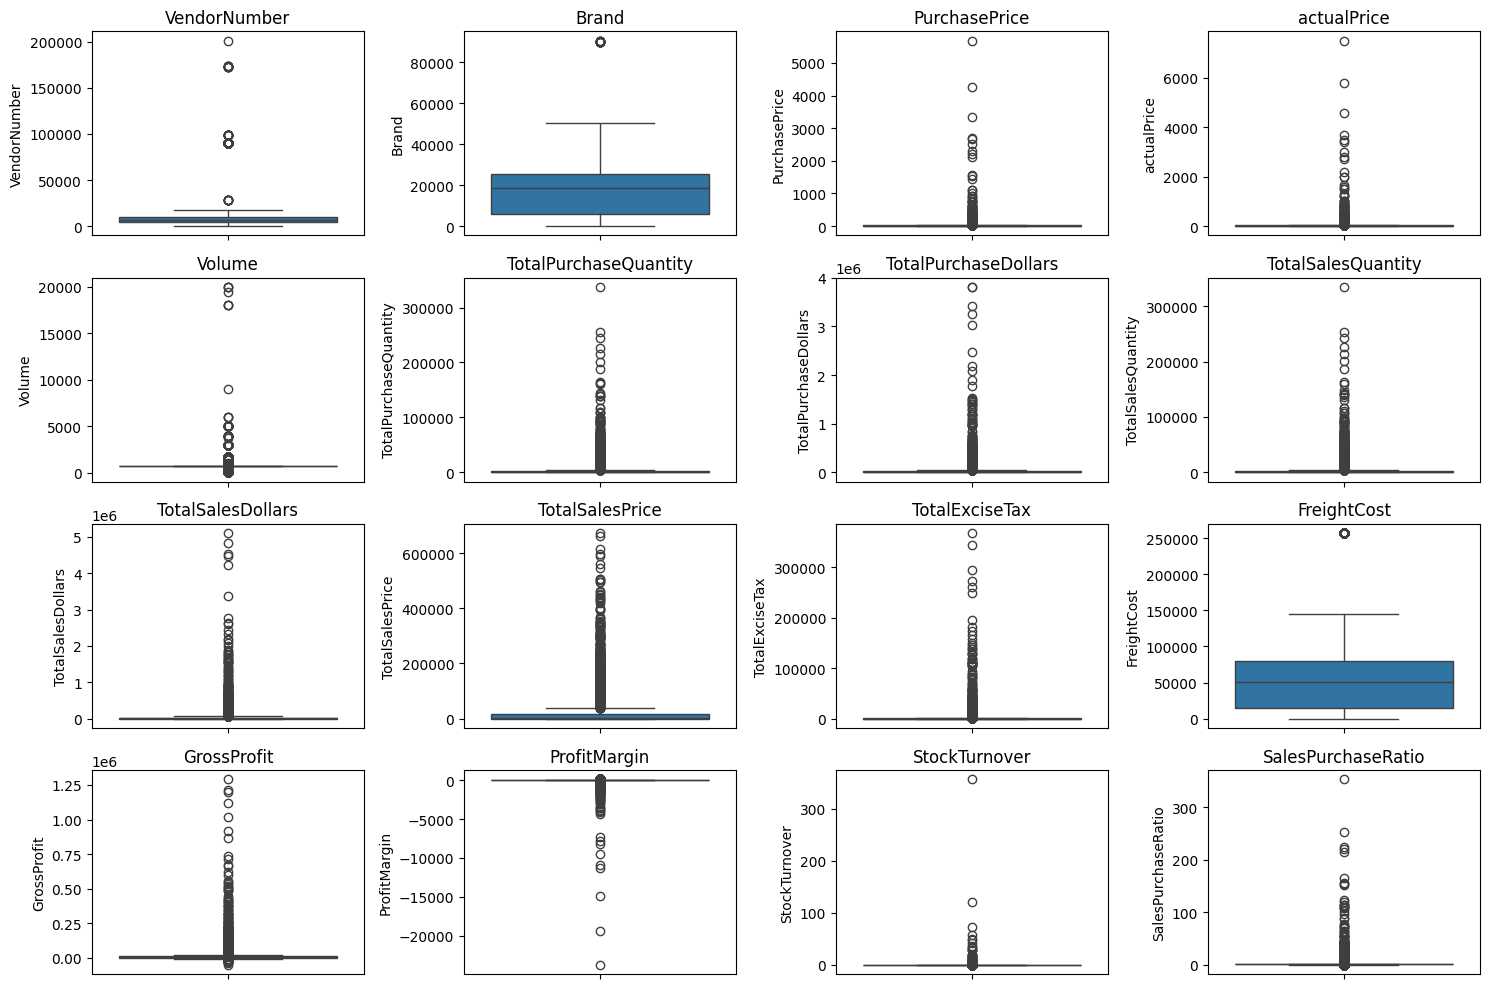

In [27]:
# Finding Outliers using boxplots
plt.figure(figsize=(15,10))
for i ,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.savefig("analysis/outliers_boxplot_02.png", dpi=300)
plt.show()
    


## Summary Statistics Insights:
Negative and zero values:
1. Gross Profit:Mininum Value is -52,002,indicating losses.Some Products or transactions may be selling at losses due ot high costs or selling discounts lower then the purchase price.
2. Profit  Margin:has min of -infinity ,which suggest case when revenue is 0 or even lower than the cost.
3. Total Sales Quantity and Sales Dollars :Minimum Values are 0 ,meaning products were purchased but never sold.These could be slow moving or obsolte stock.

Outliers Indicated by High Standard Deviations:
1. Purchase and Actual Prices :Max values(5,681.81 &7,499.99) are significantly higher than the mean (24.39&35.64),indicating portential premium products.
2. Freight Cost: Huge Variation ,from 0.09 to 257,032.07 ,suggests logstics inefficiencies or bulk shipment.
3. Stock Turnover:Ranges from 0 to 274.5 ,implying some products sell exetremely fast while others remain in stock indefinitely. Value more than 1 indicates that sold quantity for that products is higher  than purchased quantity due to either sales are being fullfilled from older stock.

In [31]:
# filtered dataset
df = pd.read_sql_query("""
SELECT * FROM Vendor_sales_summary
WHERE "GrossProfit" > 0 
AND "ProfitMargin" > 0 
AND "TotalSalesQuantity" > 0
""", conn)

print(df.shape)

(8564, 18)


In [29]:
df = pd.read_sql_query("SELECT * FROM Vendor_sales_summary", conn)
print(df.columns)

Index(['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice',
       'actualPrice', 'Volume', 'TotalPurchaseQuantity',
       'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars',
       'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit',
       'ProfitMargin', 'StockTurnover', 'SalesPurchaseRatio'],
      dtype='str')


In [32]:
df.shape

(8564, 18)

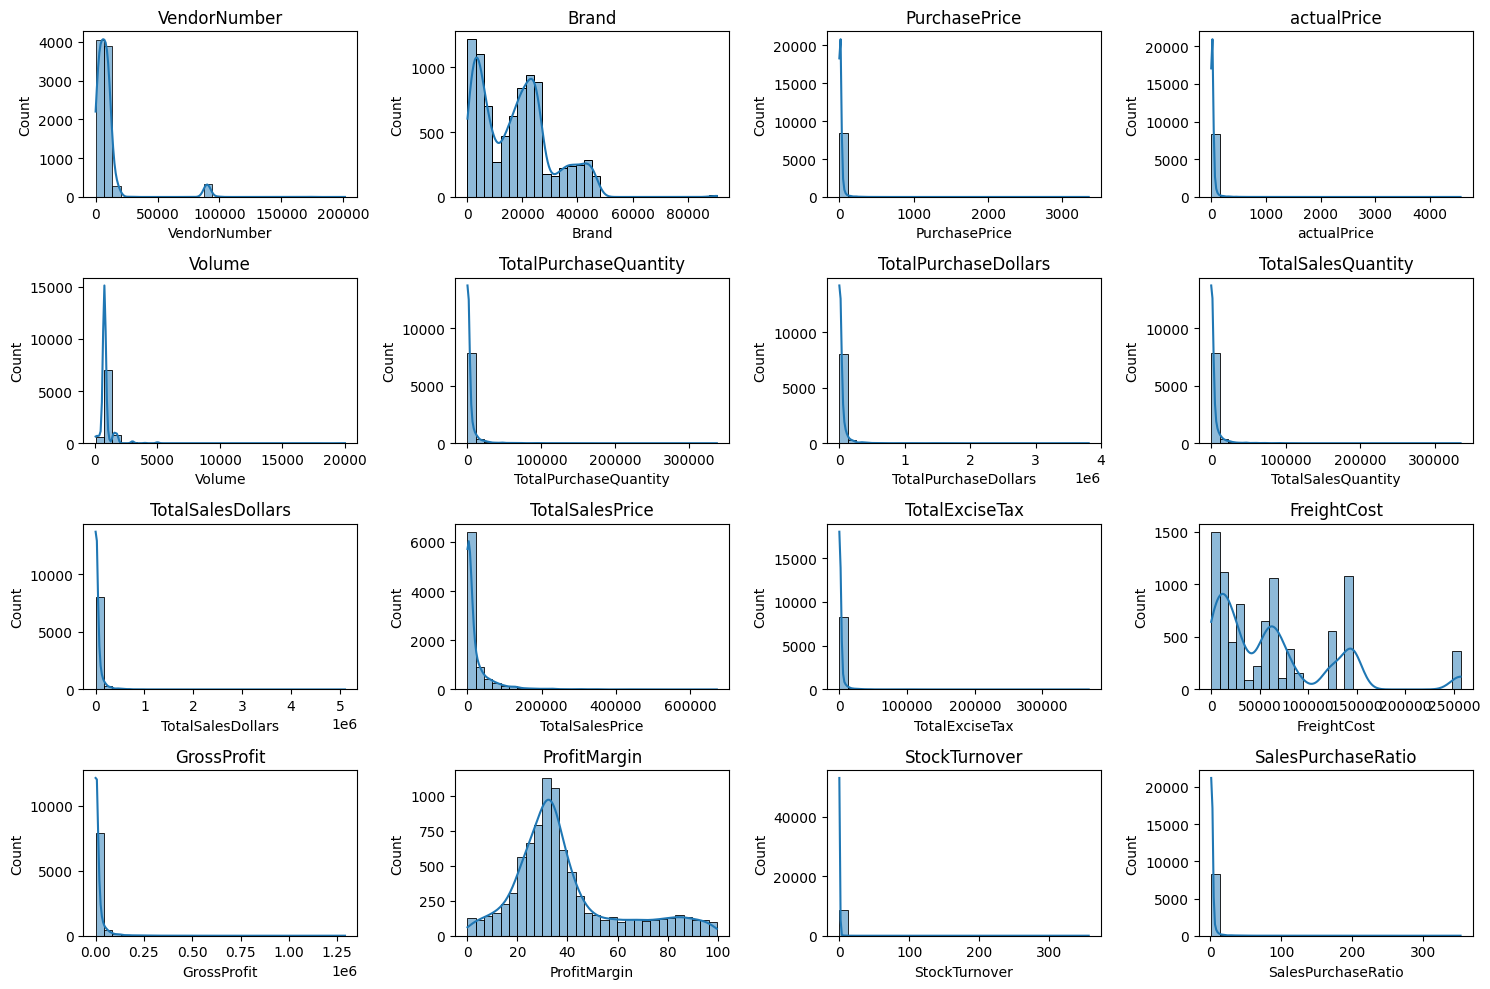

In [34]:
#After cleaning data . Dsitribution of Data is 
numerical_cols=df.select_dtypes(include=np.number).columns
plt.figure(figsize=(15,10))
for i ,col in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
    plt.tight_layout()
plt.savefig("analysis/numerical_distribution_plots_03.png", dpi=300)
plt.show()

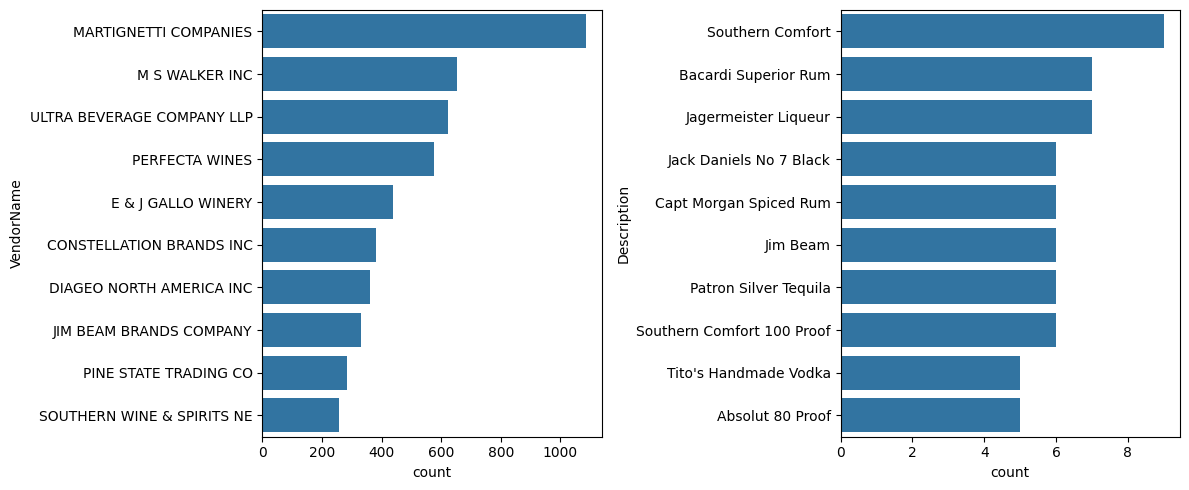

In [37]:
#count plots for categorical Columns
categorical_cols=["VendorName","Description"]
plt.figure(figsize=(12,5))
for i ,col in enumerate(categorical_cols):
    plt.subplot(1,2,i+1)
    sns.countplot(y=df[col],order=df[col].value_counts().index[:10])
plt.tight_layout()
plt.savefig("analysis/categorical_count_distribution_04.png", dpi=300)
plt.show()
    
    

    

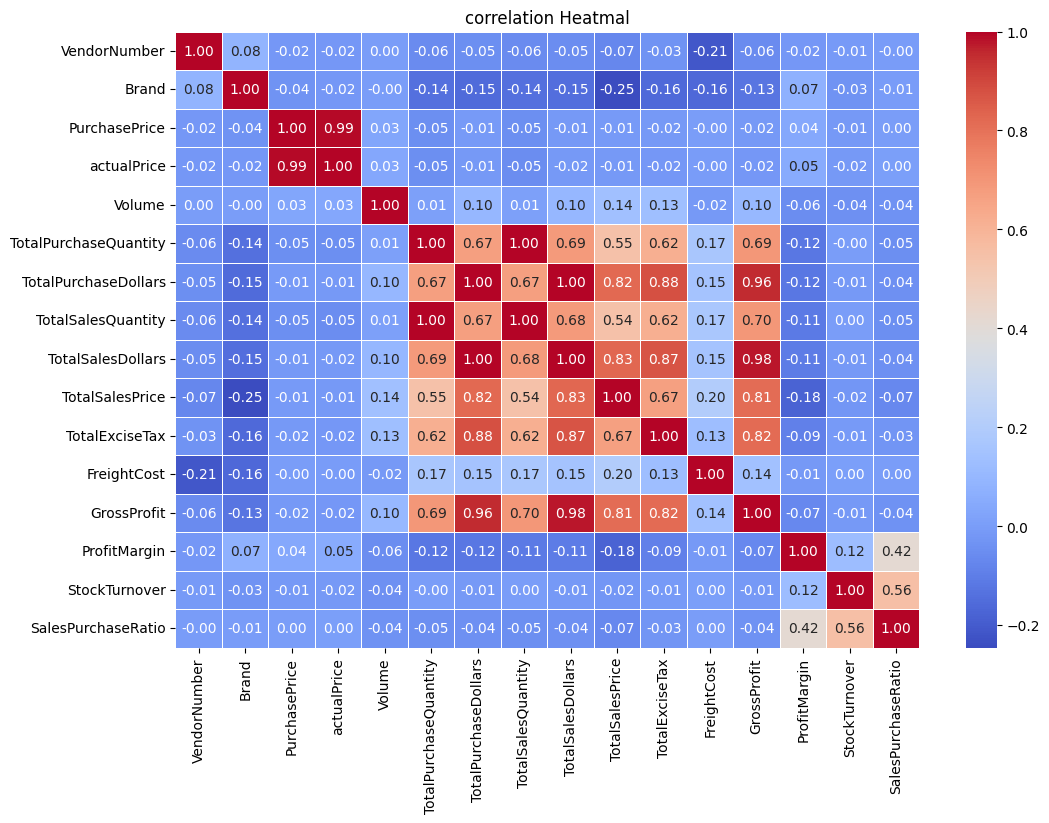

In [39]:
#Correlation
plt.figure(figsize=(12,8))
correlation_matrix=df[numerical_cols].corr()
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",linewidth=0.5)
plt.title("correlation Heatmal")
plt.savefig("analysis/correlation_heatmap_05.png", dpi=300)
plt.show()

## Correlation Insights
1. Purchase Price has weak correlations with totalsalesdollars(-0.012) and Gross Profit(-0.016) ,suggesting that  price variations donot significantly impact sales revenue or profit.
2. Strong Correlation between total purchase quantity and total sales quantity (0.999) ,confirming efficient inventory turnover.
3. Negative Correlation between profit  margin and total sales price (-0.179) suggests that as sales price increases,margins decrease ,possibly due to competitive pricing pressures.
4. Stock Turnover has weak negative correlations with both GrossPorfit (-0.038) and ProfitMargin(-0.0555) ,indicating that faster turnover does not necessarily result in higher profitability.

## Data Analysis  
Identify Brands that needs Promotional or Pricing Adjustments which exihibit lower sales performance but higher profit margins.

In [40]:
#low sales high profit
brand_performance=df.groupby('Description').agg({
    'TotalSalesDollars':'sum','ProfitMargin':'mean'}).reset_index()

In [41]:
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [48]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
High_Margin_threshold=brand_performance['ProfitMargin'].quantile(0.85)

In [43]:
low_sales_threshold
#560 dollar se kam

np.float64(560.299)

In [44]:
High_Margin_threshold
#agar 64 percentage se jayda

np.float64(64.97017552750113)

In [49]:
# filter brand with low sales but high profit margins
target_brands=brand_performance[(
    brand_performance['TotalSalesDollars']<=low_sales_threshold)&
(brand_performance['ProfitMargin']>=High_Margin_threshold)]
print("Brand with Low Sales but high Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brand with Low Sales but high Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [50]:
brand_performance=brand_performance[brand_performance['TotalSalesDollars']<10000]

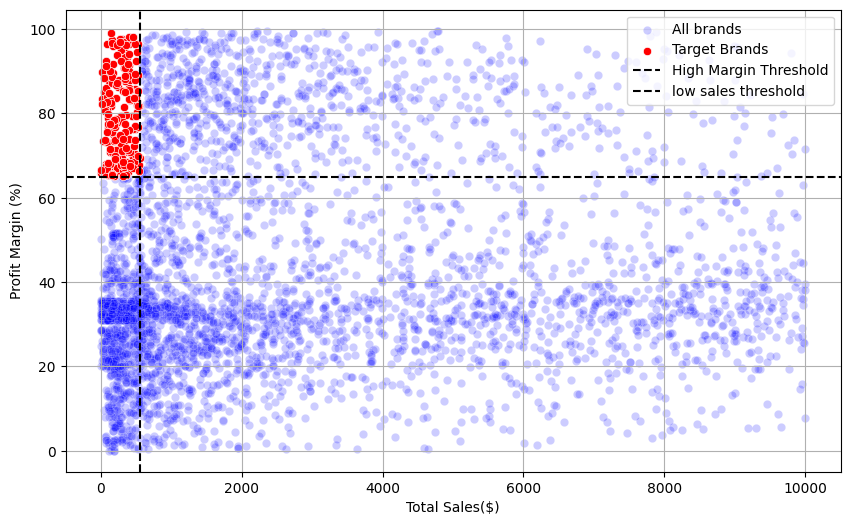

In [52]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance,x='TotalSalesDollars',y='ProfitMargin',color="Blue",label="All brands",alpha=0.2)
sns.scatterplot(data=target_brands,x='TotalSalesDollars',y='ProfitMargin',color='Red',label="Target Brands")
plt.axhline(High_Margin_threshold,linestyle='--',color='Black',label="High Margin Threshold")
plt.axvline(low_sales_threshold,linestyle='--',color='black',label="low sales threshold")
plt.xlabel("Total Sales($)")
plt.ylabel("Profit Margin (%)")
plt.legend()
plt.grid(True)
plt.savefig("analysis/low_sales_high_profit_brands_06.png", dpi=300)
plt.show()

In [53]:
def format_dollars(value):
    if value>=1_00_000:
        return f"{value/1_00_000:.2f}M"
    elif value>=1_000:
        return f"{value/1_00_000:.2f}K"
    else:
        return str(value)

## Which brand and vendors demonstrate the highest sales performance.

In [54]:
top_vendors=df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands=df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)


In [55]:
top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [56]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [57]:
top_brands.apply(lambda x:format_dollars(x))

Description
Jack Daniels No 7 Black    79.65M
Tito's Handmade Vodka      74.00M
Grey Goose Vodka           72.10M
Capt Morgan Spiced Rum     63.56M
Absolut 80 Proof           62.45M
Jameson Irish Whiskey      57.16M
Ketel One Vodka            50.70M
Baileys Irish Cream        41.50M
Kahlua                     36.05M
Tanqueray                  34.57M
Name: TotalSalesDollars, dtype: str

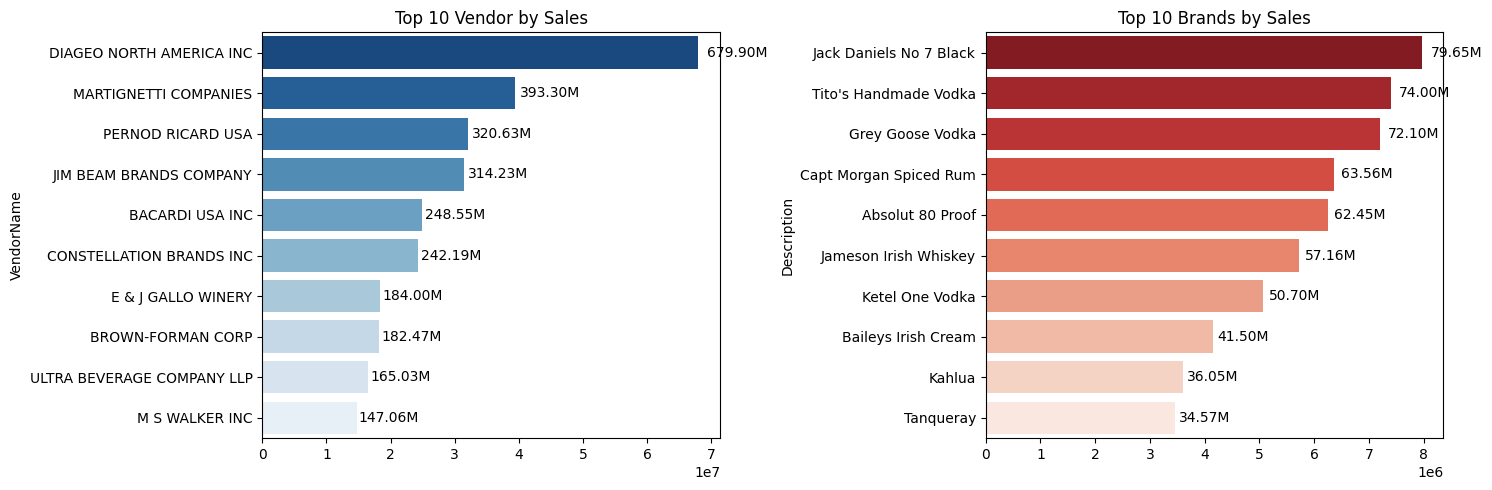

In [59]:
plt.figure(figsize=(15,5))
#plot for top vendors
plt.subplot(1,2,1)
ax1=sns.barplot(y=top_vendors.index,x=top_vendors.values,palette="Blues_r")
plt.title("Top 10 Vendor by Sales")

for bar in ax1.patches:
    ax1.text(
        bar.get_width()+bar.get_width()*0.02,
        bar.get_y()+bar.get_height()/2,
    format_dollars(bar.get_width()),
    ha='left',
    va='center',
    fontsize=10,
    color='black')
#plot for Top Brands
plt.subplot(1,2,2)
ax2=sns.barplot(y=top_brands.index.astype(str),x=top_brands.values,palette="Reds_r")
plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width()+bar.get_width()*0.02,bar.get_y()+bar.get_height()/2,
            format_dollars(bar.get_width()),
             ha='left',
             va='center',
             fontsize=10,
             color='black')
plt.tight_layout()
plt.savefig("analysis/top_vendors_and_brands_sales_07.png", dpi=300)
plt.show()


## Which vendors Contribute the most to total purchase Dollars

In [60]:
vendor_performance=df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'}).reset_index()

In [64]:
vendor_performance['PurchaseContribution%']=vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%',ascending=False),2)

In [65]:
#Display top 10 vendors
top_vendors=vendor_performance.head(10)
top_vendors['TotalSalesDollars']=top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars']=top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit']=top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,500.97M,178.93M,679.90M,16.30
57,MARTIGNETTI COMPANIES,255.02M,138.28M,393.30M,8.30
68,PERNOD RICARD USA,238.51M,82.12M,320.63M,7.76
46,JIM BEAM BRANDS COMPANY,234.94M,79.29M,314.23M,7.64
6,BACARDI USA INC,174.32M,74.23M,248.55M,5.67
20,CONSTELLATION BRANDS INC,152.74M,89.45M,242.19M,4.97
11,BROWN-FORMAN CORP,132.39M,50.08M,182.47M,4.31
30,E & J GALLO WINERY,120.69M,63.31M,184.00M,3.93
106,ULTRA BEVERAGE COMPANY LLP,111.67M,53.35M,165.03M,3.63
53,M S WALKER INC,97.64M,49.42M,147.06M,3.18


In [66]:
top_vendors['PurchaseContribution%'].sum()

np.float64(65.69000000000001)

In [67]:
top_vendors['Cumulative_Contribution%']=top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,500.97M,178.93M,679.90M,16.30,16.30
57,MARTIGNETTI COMPANIES,255.02M,138.28M,393.30M,8.30,24.60
68,PERNOD RICARD USA,238.51M,82.12M,320.63M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,234.94M,79.29M,314.23M,7.64,40.00
6,BACARDI USA INC,174.32M,74.23M,248.55M,5.67,45.67
20,CONSTELLATION BRANDS INC,152.74M,89.45M,242.19M,4.97,50.64
11,BROWN-FORMAN CORP,132.39M,50.08M,182.47M,4.31,54.95
30,E & J GALLO WINERY,120.69M,63.31M,184.00M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,111.67M,53.35M,165.03M,3.63,62.51
53,M S WALKER INC,97.64M,49.42M,147.06M,3.18,65.69


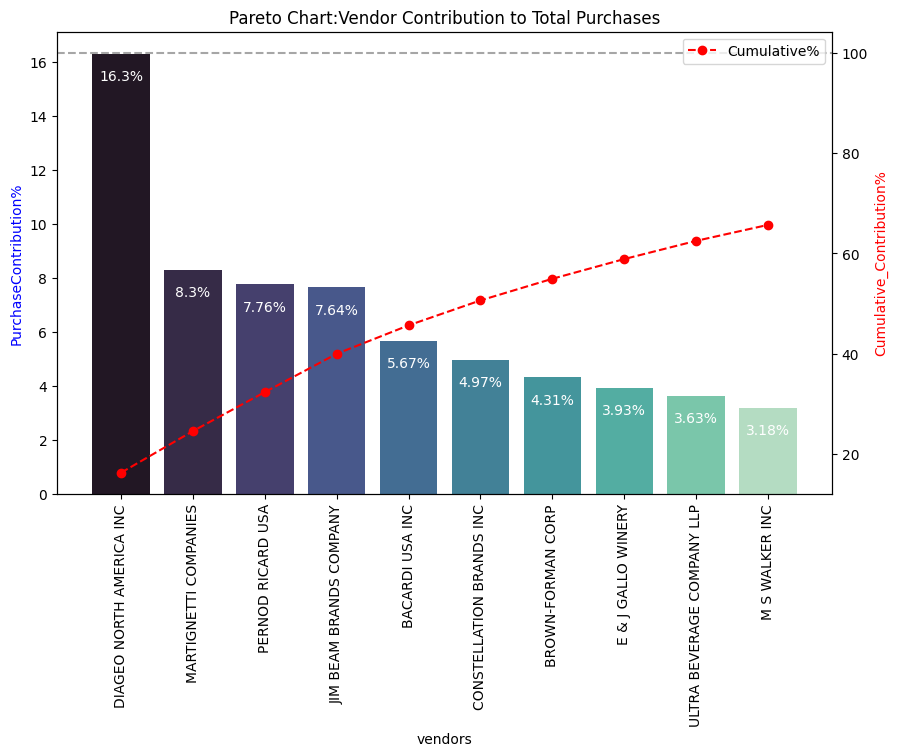

In [68]:
fig,ax1=plt.subplots(figsize=(10,6))
#Bar plot for purchase Contribution%
sns.barplot(x=top_vendors['VendorName'],y=top_vendors['PurchaseContribution%'],palette="mako",ax=ax1)
for i ,value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i,value-1,str(value)+'%',ha='center',fontsize=10,color='white')
#Line Plot for Cummulative Contributions
ax2=ax1.twinx()
ax2.plot(top_vendors['VendorName'],top_vendors['Cumulative_Contribution%'],color='Red',marker='o',linestyle='--',label='Cumulative%')
ax1.set_xticklabels(top_vendors['VendorName'],rotation=90)
ax1.set_ylabel('PurchaseContribution%',color='blue')
ax2.set_ylabel('Cumulative_Contribution%',color='red')
ax1.set_xlabel('vendors')
ax1.set_title('Pareto Chart:Vendor Contribution to Total Purchases')
ax2.axhline(y=100,color='gray',linestyle='--',alpha=0.7)
ax2.legend(loc='upper right')
plt.savefig("analysis/vendor_contribution_total_purchases_08.png", dpi=300)
plt.show() 

## How much of total procurement is dependent on the top Vendors?

In [69]:
print(f"Total Purchase Contribution of Top 10 Vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}%")


Total Purchase Contribution of Top 10 Vendors is 65.69%


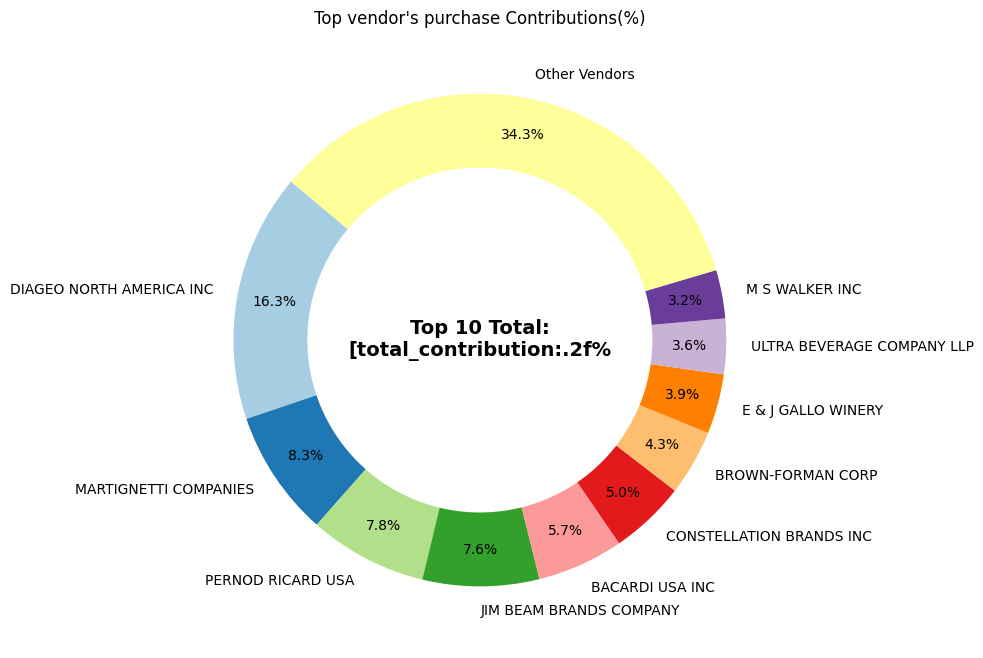

In [71]:
#Donat Chart
vendors=list(top_vendors['VendorName'].values)
purchase_contributions=list(top_vendors['PurchaseContribution%'].values)
total_contribution=sum(purchase_contributions)
remaining_contribution=100-total_contribution

#append "other vendor Category"
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)
# for chart
fig,ax=plt.subplots(figsize=(8,8))
wedges,texts,autotexts=ax.pie(purchase_contributions,labels=vendors,autopct='%1.1f%%',
                              startangle=140,pctdistance=0.85,colors=plt.cm.Paired.colors)
#Draw a white circle in the center to create a donut effect
center_circle=plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(center_circle)

plt.text(0,0,f"Top 10 Total:\n[total_contribution:.2f%",fontsize=14,fontweight='bold',ha='center',va='center')
plt.title("Top vendor's purchase Contributions(%)")
plt.savefig("analysis/vendor_purchase_contribution_donut_chart_09.png", dpi=300)
plt.show()

## Does purchasing in bulk reduce the unit price ,and what is the optimal purchase volumne of cost savings?

In [72]:
df['UnitPurchasePrice']=df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [73]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,actualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio,UnitPurchasePrice
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.037271,1.338647,26.27
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.042125,1.266830,23.19
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.054746,1.327594,18.24
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.061453,1.372493,16.17
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.044932,1.396897,21.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,1.893939,6.041667,1.32
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,57.264957,28.059829,0.39
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.351351,1.337838,0.74
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,48.979592,97.469388,1.47


In [74]:
df["OrderSize"]=pd.qcut(df["TotalPurchaseQuantity"],q=3,labels=["Small","Medium","Large"])

In [75]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,actualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesPurchaseRatio,UnitPurchasePrice,OrderSize
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,1290667.91,25.297693,0.037271,1.338647,26.27,Large
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,1015032.27,21.062810,0.042125,1.266830,23.19,Large
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,1119816.92,24.675786,0.054746,1.327594,18.24,Large
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,1214774.94,27.139908,0.061453,1.372493,16.17,Large
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,1199901.61,28.412764,0.044932,1.396897,21.89,Large
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,15.95,10.96,0.55,27100.41,13.31,83.448276,1.893939,6.041667,1.32,Small
8560,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,65.66,1.47,7.04,50293.62,63.32,96.436186,57.264957,28.059829,0.39,Small
8561,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.98,0.99,0.10,14069.87,0.50,25.252525,1.351351,1.337838,0.74,Small
8562,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,143.28,77.61,15.12,257032.07,141.81,98.974037,48.979592,97.469388,1.47,Small


In [76]:
df[['OrderSize','TotalPurchaseQuantity']]

,OrderSize,TotalPurchaseQuantity
0,Large,145080
1,Large,164038
2,Large,187407
3,Large,201682
4,Large,138109
...,...,...
8559,Small,2
8560,Small,6
8561,Small,2
8562,Small,1


In [77]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


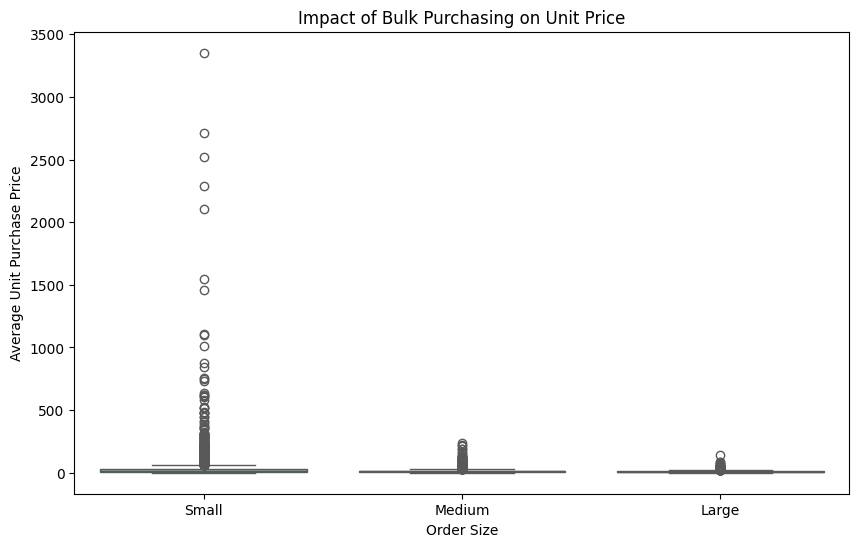

In [79]:
#means more the bulk the less is the unitprice so will will plot using box plot
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="OrderSize",y="UnitPurchasePrice",palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Average Unit Purchase Price")
plt.savefig("analysis/bulk_purchase_unit_price_boxplot_10.png", dpi=300)
plt.show()

1. Vendors buying in bulk (large size order) get the lowest unit price($10.78 per unit ),meaning higher margins if they can manage inventory efficiently.
2. The price difference between small and large orders is substaintial (72% reduction in unit cost)
3. This suggests that bulk  pricing strategies successfully encourage vendors to purchase in larger volumne,leading to higher overall sales despite lower per unit revenue.

## Which vendors have low inventory turnover,indicating excess stock and slow moving products?

In [80]:
#Stock Turn over means how may times your stock was sold and replaced in given period of time.
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)  # less tha 1 means they sell less than 1 cycle of their stock -very low sales or excess stock

,StockTurnover
VendorName,
ALTAMAR BRANDS LLC,0.034938
CALEDONIA SPIRITS INC,0.036798
MARSALLE COMPANY,0.037491
TAMWORTH DISTILLING,0.041150
DJINN SPIRITS LLC,0.041987
BULLY BOY DISTILLERS,0.044549
SWEETWATER FARM,0.046051
TALL SHIP DISTILLERY LLC,0.046322
SMOKY QUARTZ DISTILLERY LLC,0.047437


## How much inventory is unsold inventory per vendor ,and which vendors contribute most to it? 

In [81]:
df['UnsoldInventoryValue']=(df['TotalPurchaseQuantity']-df['TotalSalesQuantity'])*df["PurchasePrice"] #unsold quantity*purchasePrice
print('Total Unsold Capital:',format_dollars(df["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 27.08M


In [82]:
#Aggregated Capital Locked per Vendor
inventory_value_per_vendor=df.groupby("VendorName")["UnsoldInventoryValue"].sum().sort_values(ascending=False).reset_index()
#Sort Vendors with higest Locked Capital
inventory_value_per_vendor=inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue",ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue']=inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
0,DIAGEO NORTH AMERICA INC,7.22M
1,JIM BEAM BRANDS COMPANY,5.55M
2,PERNOD RICARD USA,4.71M
3,WILLIAM GRANT & SONS INC,4.02M
4,E & J GALLO WINERY,2.28M
5,SAZERAC CO INC,1.98M
6,BROWN-FORMAN CORP,1.78M
7,CONSTELLATION BRANDS INC,1.34M
8,MOET HENNESSY USA INC,1.26M
9,REMY COINTREAU USA INC,1.19M


## What is the 95% confidence interval for profit marginsof top performing and low-performing vendors.

In [83]:
# Set Threshold
top_threshold=df["TotalSalesDollars"].quantile(0.75)
low_threshold=df["TotalSalesDollars"].quantile(0.25)

In [84]:
top_vendors=df[df["TotalSalesDollars"]>=top_threshold]["ProfitMargin"].dropna()
low_vendors=df[df["TotalSalesDollars"]<=low_threshold]["ProfitMargin"].dropna()

In [85]:
top_vendors


0       25.297693
1       21.062810
2       24.675786
3       27.139908
4       28.412764
          ...    
3523    79.684817
3681    85.782102
4751    93.085860
4920    95.012530
5050    94.271857
Name: ProfitMargin, Length: 2141, dtype: float64

In [86]:
low_vendors

5631     4.111764
5652     6.145626
5701    12.007271
5704     1.677308
5724     7.239599
          ...    
8559    83.448276
8560    96.436186
8561    25.252525
8562    98.974037
8563    99.166079
Name: ProfitMargin, Length: 2141, dtype: float64

In [87]:
def confidence_interval(data,confidence=0.95):
    mean_val=np.mean(data)
    std_err=np.std(data,ddof=1)/np.sqrt(len(data))
    t_critical=stats.t.ppf((1+confidence)/2,df=len(data)-1)
    margin_of_error=t_critical*std_err
    return mean_val,mean_val-margin_of_error,mean_val+margin_of_error

Top Vendors 95% CI:(30.74,31.61),Mean:31.18
Low Vendors 95% CI:(40.50,42.64),Mean:41.57


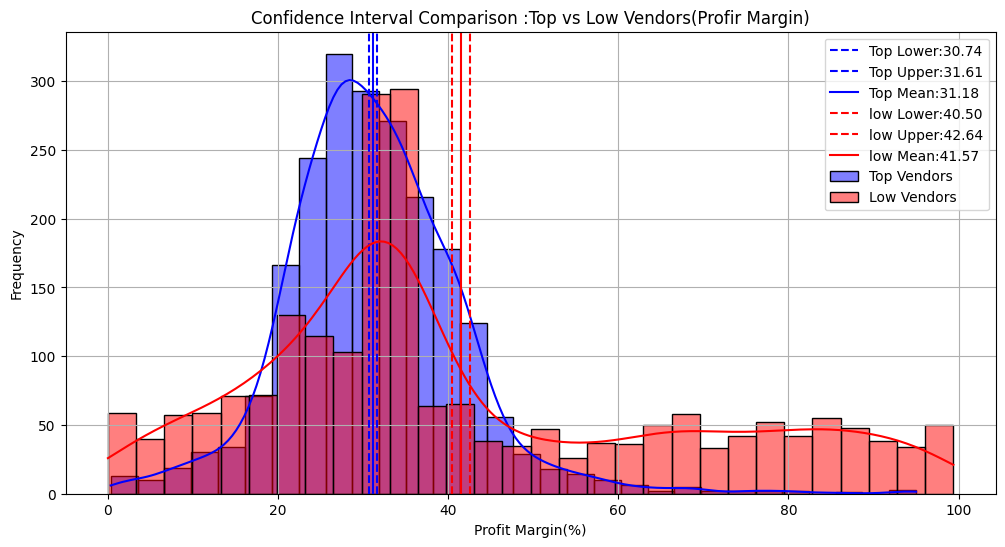

In [88]:
top_mean,top_lower,top_upper=confidence_interval(top_vendors)
low_mean,low_lower,low_upper=confidence_interval(low_vendors)
print(f"Top Vendors 95% CI:({top_lower:.2f},{top_upper:.2f}),Mean:{top_mean:.2f}")
print(f"Low Vendors 95% CI:({low_lower:.2f},{low_upper:.2f}),Mean:{low_mean:.2f}")
plt.figure(figsize=(12,6))
#Top Vendors Plot
sns.histplot(top_vendors,kde=True,color="blue",bins=30,alpha=0.5,label="Top Vendors")
plt.axvline(top_lower,color='Blue',linestyle='--',label=f"Top Lower:{top_lower:.2f}")
plt.axvline(top_upper,color='Blue',linestyle='--',label=f"Top Upper:{top_upper:.2f}")
plt.axvline(top_mean,color='Blue',linestyle='-',label=f"Top Mean:{top_mean:.2f}")


#low vendor plot
sns.histplot(low_vendors,kde=True,color="red",bins=30,alpha=0.5,label="Low Vendors")
plt.axvline(low_lower,color='red',linestyle='--',label=f"low Lower:{low_lower:.2f}")
plt.axvline(low_upper,color='red',linestyle='--',label=f"low Upper:{low_upper:.2f}")
plt.axvline(low_mean,color='red',linestyle='-',label=f"low Mean:{low_mean:.2f}")

#Finalize Plot
plt.title("Confidence Interval Comparison :Top vs Low Vendors(Profir Margin)")
plt.xlabel("Profit Margin(%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

1. Vendor with low sales tend to maintain higher profit margins,potentially due to premium pricing or lower oprational costs.
2. for high performing vendors:if they aim to improve Profitability,they could explore selective price adjustments ,cost optimization  or bundling strategies.
3. for low performing vendors:Despite higher margins ,their low sales column might indicate a need for better marketing ,competitive pricing or improve distribution strategies.

# is this a significant difference in profit margins between top-performing and low performing vendors?
hypothesis:

H(Null Hupothesis)=There is no significant diffrence in the mean profit margins of top performing and low  performing vendors.

H(Alternative Hypothesis)=The Mean profit  margins of top performing and lowe performing vendors are significantly different.

In [ ]:
top_threshold=df["TotalSalesDollars"].quantile(0.75)
low_threshold=df["TotalSalesDollars"].quantile(0.25)

top_vendors=df[df["TotalSalesDollars"]>=top_threshold]["ProfitMargin"].dropna()
low_vendors=df[df["TotalSalesDollars"]<=low_threshold]["ProfitMargin"].dropna()

#perform  two sample t test
t_stat,p_value=ttest_ind(top_vendors,low_vendors,equal_var=False)
#Prints results
print(f"T-Statistic:{t_stat:.4f},P-value:{p_value:.4f}")
if p_value<0.05:
    print("Reject Ho:There is a significant diffrence in the mean profit margins of top performing and low performing vendors.")
else:
    print("Fail to reject Ho:No significant difference in profit margin of top performing and low performing vendors are significantly different.")

T-Statistic:-17.6695,P-value:0.0000
Reject Ho:There is a significant diffrence in the mean profit margins of top performing and low performing vendors.
